In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vamos import optimize
from vamos.foundation.quality_indicators import compute_hypervolume
from vamos.engine.tuning import (
    ModelBasedTuner,
    TuningTask,
    Instance,
    EvalContext,
    build_nsgaii_config_space,
    config_from_assignment,
    save_history_csv,
)

plt.style.use("ggplot")
print("Imports OK")

Imports OK


Definimos el espacio de parámetros

In [2]:
config_space = build_nsgaii_config_space()
param_space = config_space.to_param_space()
print(f"Parameters ({len(param_space.params)}):")
for name, p in param_space.params.items():
    print(f"  {name}: {type(p).__name__}", end="")
    if hasattr(p, "low"):
        print(f" [{p.low}, {p.high}]", end="")
    if hasattr(p, "choices"):
        print(f" {list(p.choices)}", end="")
    print()

if param_space.conditions:
    print(f"\nConditional params: {len(param_space.conditions)}")

Parameters (35):
  pop_size: Int [20, 200]
  offspring_ratio: Categorical [0, 0.25, 0.5, 0.75, 1.0]
  selection: Categorical ['tournament', 'random', 'boltzmann', 'ranking', 'sus']
  use_external_archive: Boolean
  initializer: Categorical ['random', 'lhs', 'scatter', 'sobol', 'halton', 'obl']
  crossover: Categorical ['sbx', 'blx_alpha', 'blx_alpha_beta', 'arithmetic', 'whole_arithmetic', 'laplace', 'fuzzy', 'pcx', 'undx', 'simplex']
  crossover_prob: Real [0.6, 1.0]
  mutation: Categorical ['polynomial', 'linked_polynomial', 'non_uniform', 'gaussian', 'uniform_reset', 'cauchy', 'uniform', 'levy_flight', 'power_law']
  mutation_prob_factor: Real [0.25, 3.0]
  mutation_eta: Real [5.0, 40.0]
  repair: Categorical ['clip', 'reflect', 'random', 'round', 'wrap', 'midpoint']
  archive_unbounded: Boolean
  archive_prune_policy: Categorical ['crowding', 'hv', 'mc_hv', 'knn', 'maxmin', 'ref_dirs']
  selection_size: Int [2, 10]
  crossover_eta: Real [5.0, 40.0]
  crossover_alpha: Real [0.0, 1.0

Definición de instancias

In [3]:
# Parámetros globales para los problemas ZCAT
N_VAR = 30
N_OBJ = 2  # Usaremos 2 objetivos para este ejemplo
LEVEL = 1

instances = [
    Instance(name="zcat1", n_var=N_VAR, kwargs={}),
]

Ajuste función de evaluación

In [4]:
import numpy as np
from vamos import optimize
from vamos.foundation.quality_indicators import compute_hypervolume
from vamos.engine.tuning import EvalContext, config_from_assignment

# Punto de referencia para el hipervolumen (ajustado a N_OBJ) // Valor máximo de hipervolumen (a partir de aqui descartamos)
REF_POINT = np.array([1.1] * N_OBJ)

def eval_fn(config: dict, ctx: EvalContext) -> float:
    """Evalúa NSGA-II en una instancia ZCAT específica."""
    
    # Aseguramos un pop_size por defecto si no viene en el config
    if "pop_size" not in config:
        config["pop_size"] = 100
        
    cfg = config_from_assignment("nsgaii", config)

    # Ejecución de la optimización pasando los kwargs de la instancia
    result = optimize(
        ctx.instance.name,
        algorithm="nsgaii",
        algorithm_config=cfg,
        max_evaluations=ctx.budget,
        seed=ctx.seed,
        n_var=ctx.instance.n_var,
        engine="numpy",
        **ctx.instance.kwargs  # Pasa n_obj, level, etc.
    )

    if result.F is None or len(result.F) == 0:
        return 0.0
        
    return compute_hypervolume(result.F, REF_POINT)

Configuración de la tarea

In [5]:
from vamos.engine.tuning import ModelBasedTuner, TuningTask, build_nsgaii_config_space

# 1. Obtener el espacio de configuración pre-construido
config_space = build_nsgaii_config_space()
param_space = config_space.to_param_space()

# 2. Definir la tarea de tuning
task = TuningTask(
    name="zcat_tuning_task",
    param_space=param_space,
    instances=instances,
    seeds=[0, 1],                # 2 semillas para demostración rápida
    budget_per_run=15000,         # FEs por ejecución de MOEA
    maximize=True,
    aggregator=lambda scores: float(np.mean(scores)),
)

/home/usuario/david/TFM/.venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/usuario/david/TFM/.venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-08 06:45:02,215] A new study created in memory with name: no-name-cba0d3a9-da32-455f-8ab8-91ec4401a882



--- Running sampler: tpe ---


[I 2026-05-08 06:45:18,392] Trial 0 finished with value: 0.2340517592656179 and parameters: {'pop_size': 47, 'offspring_ratio': 0, 'selection': 'random', 'use_external_archive': False, 'initializer': 'halton', 'crossover': 'fuzzy', 'crossover_prob': 0.6185801650879991, 'mutation': 'uniform_reset', 'mutation_prob_factor': 1.4604193577839035, 'mutation_eta': 9.271338219567259, 'repair': 'random', 'archive_unbounded': True, 'archive_prune_policy': 'hv', 'selection_size': 10, 'crossover_eta': 8.097237571817182, 'crossover_alpha': 0.1959828624191452, 'blxab_alpha': 0.045227288910538066, 'blxab_beta': 0.32533033076326434, 'wa_alpha': 0.388677289689482, 'laplace_a': -0.4573019364522082, 'laplace_b': 1.6591876432123394, 'fuzzy_d': 0.7135066533871786, 'pcx_sigma_eta': 0.14765790974681658, 'pcx_sigma_zeta': 0.27592108074754174, 'undx_zeta': 0.2268318024772864, 'undx_eta': 0.8219772826786357, 'simplex_epsilon': 0.16709557931179375, 'nonuniform_perturbation': 0.49409912147023277, 'gaussian_sigma':

  Best HV: 0.252145  |  Mean: 0.180595

--- Running sampler: cmaes ---


[I 2026-05-08 06:55:58,092] Trial 0 finished with value: 0.2340517592656179 and parameters: {'pop_size': 47, 'offspring_ratio': 0, 'selection': 'random', 'use_external_archive': False, 'initializer': 'halton', 'crossover': 'fuzzy', 'crossover_prob': 0.6185801650879991, 'mutation': 'uniform_reset', 'mutation_prob_factor': 1.4604193577839035, 'mutation_eta': 9.271338219567259, 'repair': 'random', 'archive_unbounded': True, 'archive_prune_policy': 'hv', 'selection_size': 10, 'crossover_eta': 8.097237571817182, 'crossover_alpha': 0.1959828624191452, 'blxab_alpha': 0.045227288910538066, 'blxab_beta': 0.32533033076326434, 'wa_alpha': 0.388677289689482, 'laplace_a': -0.4573019364522082, 'laplace_b': 1.6591876432123394, 'fuzzy_d': 0.7135066533871786, 'pcx_sigma_eta': 0.14765790974681658, 'pcx_sigma_zeta': 0.27592108074754174, 'undx_zeta': 0.2268318024772864, 'undx_eta': 0.8219772826786357, 'simplex_epsilon': 0.16709557931179375, 'nonuniform_perturbation': 0.49409912147023277, 'gaussian_sigma':

...

[I 2026-05-08 08:03:40,521] Trial 0 finished with value: 0.2340517592656179 and parameters: {'pop_size': 47, 'offspring_ratio': 0, 'selection': 'random', 'use_external_archive': False, 'initializer': 'halton', 'crossover': 'fuzzy', 'crossover_prob': 0.6185801650879991, 'mutation': 'uniform_reset', 'mutation_prob_factor': 1.4604193577839035, 'mutation_eta': 9.271338219567259, 'repair': 'random', 'archive_unbounded': True, 'archive_prune_policy': 'hv', 'selection_size': 10, 'crossover_eta': 8.097237571817182, 'crossover_alpha': 0.1959828624191452, 'blxab_alpha': 0.045227288910538066, 'blxab_beta': 0.32533033076326434, 'wa_alpha': 0.388677289689482, 'laplace_a': -0.4573019364522082, 'laplace_b': 1.6591876432123394, 'fuzzy_d': 0.7135066533871786, 'pcx_sigma_eta': 0.14765790974681658, 'pcx_sigma_zeta': 0.27592108074754174, 'undx_zeta': 0.2268318024772864, 'undx_eta': 0.8219772826786357, 'simplex_epsilon': 0.16709557931179375, 'nonuniform_perturbation': 0.49409912147023277, 'gaussian_sigma':

  Best HV: 0.252631  |  Mean: 0.151302

--- Running sampler: gp ---


[I 2026-05-08 08:17:20,323] Trial 0 finished with value: 0.2340517592656179 and parameters: {'pop_size': 47, 'offspring_ratio': 0, 'selection': 'random', 'use_external_archive': False, 'initializer': 'halton', 'crossover': 'fuzzy', 'crossover_prob': 0.6185801650879991, 'mutation': 'uniform_reset', 'mutation_prob_factor': 1.4604193577839035, 'mutation_eta': 9.271338219567259, 'repair': 'random', 'archive_unbounded': True, 'archive_prune_policy': 'hv', 'selection_size': 10, 'crossover_eta': 8.097237571817182, 'crossover_alpha': 0.1959828624191452, 'blxab_alpha': 0.045227288910538066, 'blxab_beta': 0.32533033076326434, 'wa_alpha': 0.388677289689482, 'laplace_a': -0.4573019364522082, 'laplace_b': 1.6591876432123394, 'fuzzy_d': 0.7135066533871786, 'pcx_sigma_eta': 0.14765790974681658, 'pcx_sigma_zeta': 0.27592108074754174, 'undx_zeta': 0.2268318024772864, 'undx_eta': 0.8219772826786357, 'simplex_epsilon': 0.16709557931179375, 'nonuniform_perturbation': 0.49409912147023277, 'gaussian_sigma':

  Best HV: 0.244077  |  Mean: 0.209625


TypeError: cannot accumulate on a scalar

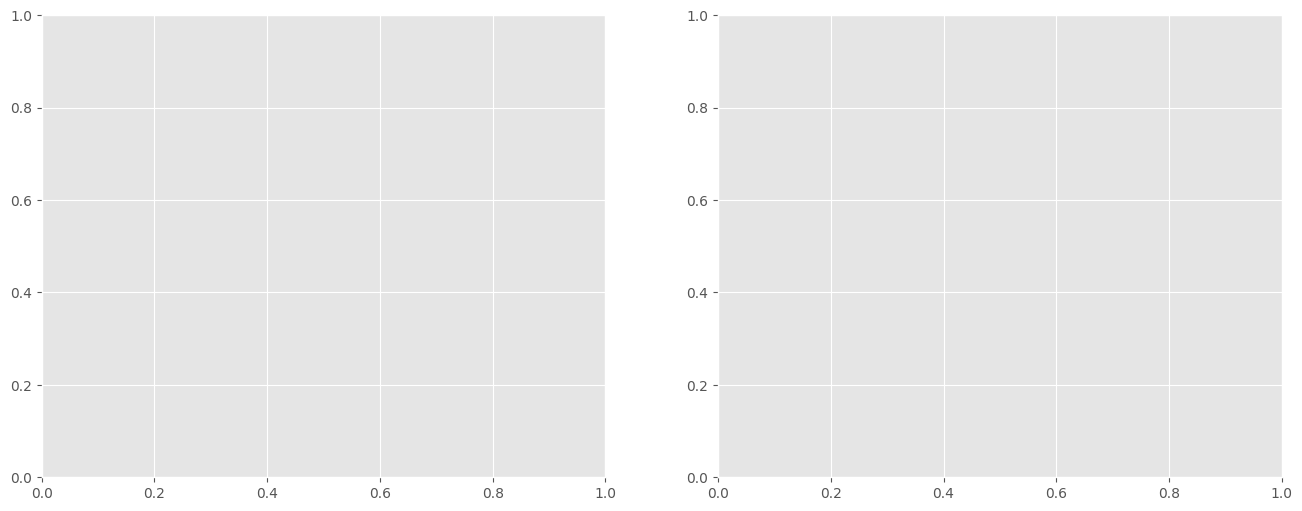

In [ ]:
MAX_TRIALS = 50  # configs per sampler (small for demo)
SAMPLERS = ["tpe", "cmaes", "random", "nsgaii", "nsgaiii", "qmc", "gp"]
results = {}

for sampler_name in SAMPLERS:
    print(f"\n--- Running sampler: {sampler_name} ---")

    tuner = ModelBasedTuner(
        task=task,
        max_trials=MAX_TRIALS,
        backend="optuna",
        optuna_sampler=sampler_name,
        seed=42,
        n_jobs=1,
    )

    best_config, history = tuner.run(eval_fn)
    scores = [t.score for t in history]
    results[sampler_name] = {
        "best_config": best_config,
        "history": history,
        "scores": scores,
        "best": max(scores),
    }
    print(f"  Best HV: {max(scores):.6f}  |  Mean: {np.mean(scores):.6f}")

/tmp/ipykernel_413559/1850617430.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=list(results.keys()), patch_artist=True)


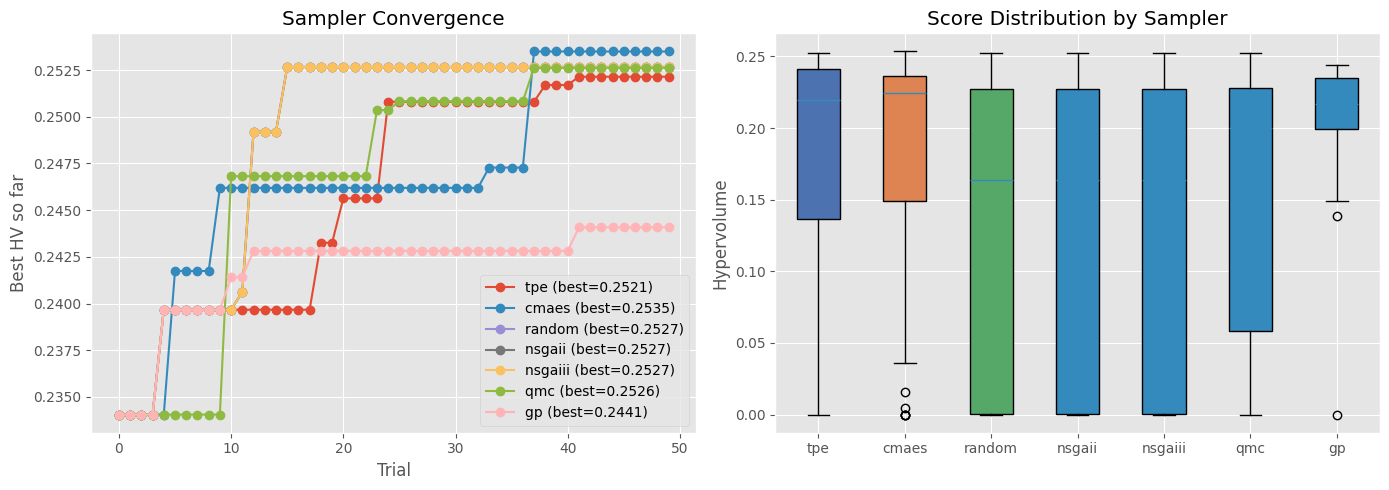

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence curves
for name, res in results.items():
    best_so_far = np.maximum.accumulate(res["scores"])
    axes[0].plot(best_so_far, "o-", label=f"{name} (best={res['best']:.4f})")

axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Best HV so far")
axes[0].set_title("Sampler Convergence")
axes[0].legend()

# Box plot
data = [res["scores"] for res in results.values()]
bp = axes[1].boxplot(data, labels=list(results.keys()), patch_artist=True)
colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel("Hypervolume")
axes[1].set_title("Score Distribution by Sampler")

plt.tight_layout()
plt.show()

In [10]:
# Pick the best sampler's history
best_sampler = max(results, key=lambda s: results[s]["best"])
best_history = results[best_sampler]["history"]

save_history_csv(best_history, param_space,"tuning_results.csv")
print(f"Saved {len(best_history)} trials to tuning_results.csv")

# Quick peek
df = pd.DataFrame([
    {"trial": t.trial_id, "score": t.score, **t.config}
    for t in best_history
])
df.head(10)

Saved 50 trials to tuning_results.csv


,trial,score,pop_size,offspring_ratio,selection,use_external_archive,initializer,crossover,crossover_prob,mutation,...,undx_eta,simplex_epsilon,nonuniform_perturbation,gaussian_sigma,cauchy_gamma,uniform_perturb,levy_beta,levy_scale,power_index,scatter_base_size_factor
0,0,0.234052,47,0.00,random,False,halton,fuzzy,0.618580,uniform_reset,...,0.821977,0.167096,0.494099,0.386350,0.100159,0.012706,1.723192,0.070979,3.780532,0.75
1,1,0.221468,74,1.00,random,False,random,whole_arithmetic,0.871808,non_uniform,...,0.498286,0.546325,0.308225,0.173255,0.130766,0.174696,1.131758,0.071656,3.835948,0.20
2,2,0.223821,48,0.00,boltzmann,True,sobol,undx,0.842344,gaussian,...,0.764378,0.708430,0.218859,0.291887,0.139389,0.135941,1.304249,0.044619,3.631724,0.30
3,3,0.099114,71,0.25,boltzmann,True,sobol,laplace,0.781562,non_uniform,...,0.581688,0.593112,0.266682,0.399118,0.241697,0.333671,1.212104,0.047870,3.235499,0.10
4,4,0.004830,108,0.75,ranking,True,obl,blx_alpha_beta,0.814180,power_law,...,0.386393,0.800459,0.303014,0.227178,0.205561,0.272030,1.272834,0.032901,2.791761,0.20
5,5,0.241743,75,0.75,tournament,True,scatter,undx,0.769232,power_law,...,0.697293,0.679386,0.245591,0.382242,0.362746,0.346992,0.977270,0.051704,3.533724,1.00
6,6,0.133822,81,0.00,sus,True,halton,laplace,0.814485,polynomial,...,0.372945,0.580910,0.241863,0.208826,0.230949,0.389628,1.086730,0.055025,3.607385,0.30
7,7,0.000000,60,0.75,boltzmann,True,obl,whole_arithmetic,0.770546,linked_polynomial,...,0.333557,0.462510,0.290050,0.139361,0.182091,0.289705,1.383806,0.073444,1.630695,0.10
8,8,0.235759,41,1.00,boltzmann,False,obl,sbx,0.843769,gaussian,...,0.443505,0.703794,0.282644,0.286623,0.134212,0.164898,0.809391,0.033683,1.267033,0.10
9,9,0.246194,69,0.50,tournament,True,halton,blx_alpha_beta,0.805976,non_uniform,...,0.723757,0.506093,0.234624,0.111873,0.217082,0.227606,1.524588,0.068887,3.101673,1.00


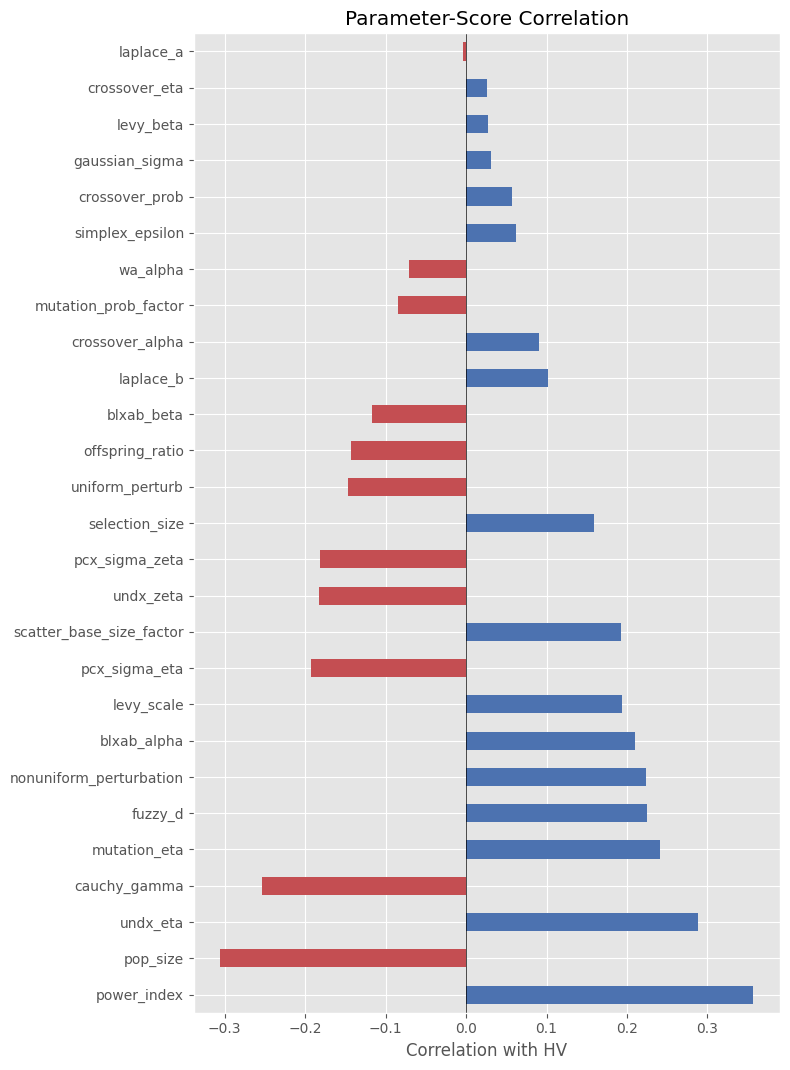

In [11]:
# Correlation between each param and score
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ("trial", "score")]

if numeric_cols:
    correlations = {col: df["score"].corr(df[col]) for col in numeric_cols}
    corr_series = pd.Series(correlations).sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(8, max(3, len(corr_series) * 0.4)))
    colors = ["#4C72B0" if v > 0 else "#C44E52" for v in corr_series]
    corr_series.plot.barh(ax=ax, color=colors)
    ax.set_xlabel("Correlation with HV")
    ax.set_title("Parameter-Score Correlation")
    ax.axvline(0, color="black", lw=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric parameters to analyze.")